In [34]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Image

%matplotlib inline
pd.options.display.float_format = '{:,.2f}'.format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

In [35]:
df = pd.read_csv('Impute_misvalues_hungyen.csv')
df.head()

,Date,Hour,Waterlevel
0,1/1/2008,0,47.00
1,1/1/2008,1,43.00
2,1/1/2008,2,40.00
3,1/1/2008,3,37.00
4,1/1/2008,4,34.00


In [36]:
df['Hour'] = df['Hour'].replace('#NUM!', 0)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64061 entries, 0 to 64060
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        64061 non-null  object 
 1   Hour        64061 non-null  object 
 2   Waterlevel  64061 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.5+ MB


In [38]:
df.isnull().sum()

Date          0
Hour          0
Waterlevel    0
dtype: int64

In [39]:
# df.loc[df['Hour'] == 'NUM!', 'Hour'] = 0
df['Hour'] = pd.to_datetime(df['Hour'], format='%H', errors='coerce').dt.time
df.head()

,Date,Hour,Waterlevel
0,1/1/2008,00:00:00,47.00
1,1/1/2008,01:00:00,43.00
2,1/1/2008,02:00:00,40.00
3,1/1/2008,03:00:00,37.00
4,1/1/2008,04:00:00,34.00


In [40]:
df['Hour'] = df['Hour'].astype(str)


df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'])
df = df.set_index('DateTime')
df.drop(['Date', 'Hour'], axis = 1, inplace = True)

df.head()

,Waterlevel
DateTime,
2008-01-01 00:00:00,47.00
2008-01-01 01:00:00,43.00
2008-01-01 02:00:00,40.00
2008-01-01 03:00:00,37.00
2008-01-01 04:00:00,34.00


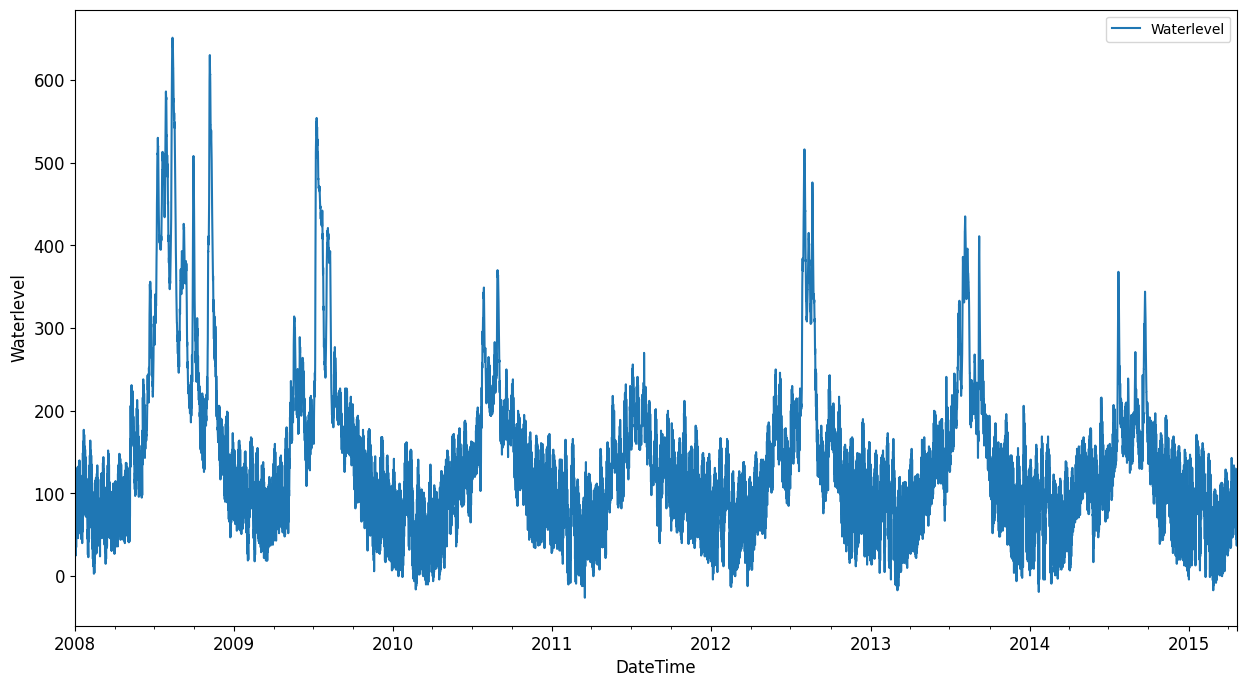

In [41]:
df.plot(y='Waterlevel', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)
plt.show()

In [42]:
train_size = int(len(df) * 0.8)
train, test = df[:train_size].iloc[:, [-1]], df[train_size:].iloc[:, [-1]]

train, test

(                     Waterlevel
 DateTime                       
 2008-01-01 00:00:00       47.00
 2008-01-01 01:00:00       43.00
 2008-01-01 02:00:00       40.00
 2008-01-01 03:00:00       37.00
 2008-01-01 04:00:00       34.00
 ...                         ...
 2013-11-05 03:00:00      107.00
 2013-11-05 04:00:00      120.00
 2013-11-05 05:00:00      133.00
 2013-11-05 06:00:00      146.00
 2013-11-05 07:00:00      159.00
 
 [51248 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2013-11-05 08:00:00      166.00
 2013-11-05 09:00:00      165.00
 2013-11-05 10:00:00      161.00
 2013-11-05 11:00:00      155.00
 2013-11-05 12:00:00      148.00
 ...                         ...
 2015-04-23 00:00:00      127.00
 2015-04-23 01:00:00      124.00
 2015-04-23 02:00:00      120.00
 2015-04-23 03:00:00      115.00
 2015-04-23 04:00:00      109.00
 
 [12813 rows x 1 columns])

In [43]:
train.shape, test.shape

((51248, 1), (12813, 1))

Text(0, 0.5, 'Waterlevel')

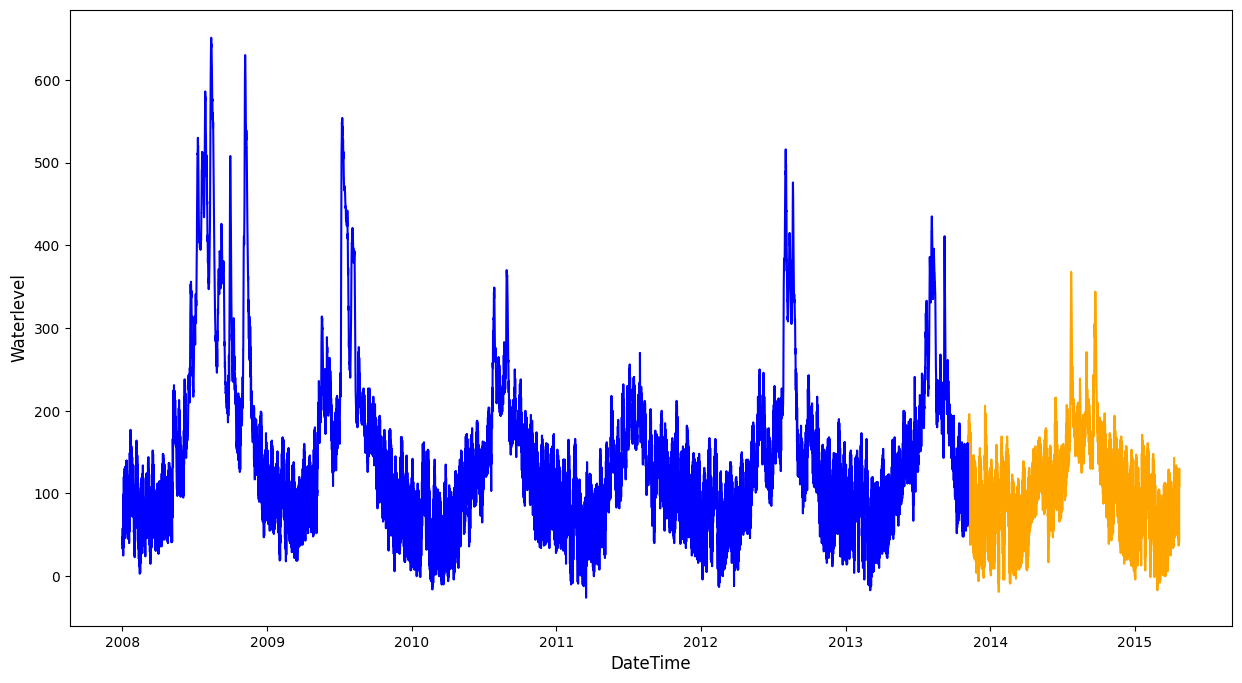

In [44]:
plt.figure(figsize = (15,8))
plt.plot(test.index, test['Waterlevel'], label = "test", color = 'orange')
plt.plot(train.index, train['Waterlevel'], label = "train" , color = 'blue')
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)

In [45]:
scaler = MinMaxScaler()
train['Waterlevel'] = scaler.fit_transform(train)

In [46]:
test['Waterlevel'] = scaler.transform(test)

In [47]:
# Specify the number of steps to forecast ahead
HORIZON = 6
print('Forecasting horizon:', HORIZON, 'hours')

Forecasting horizon: 6 hours


In [48]:
from pmdarima import auto_arima
import pandas as pd

auto_model = auto_arima(train, start_p=1, start_q=1,
                        test='adf',       # Use adftest to find optimal 'd'
                        max_p=3, max_q=3, # Maximum p and q
                        m=12,              # Frequency of the series
                        d=None,           # Let the model determine 'd'
                        seasonal=True,   # No Seasonality
                        start_P=0, 
                        D=1, 
                        trace=True,
                        error_action='ignore',  
                        suppress_warnings=True, 
                        stepwise=True)


order = auto_model.order
seasonal_order = auto_model.seasonal_order

# Fit the SARIMAX model using the best found parameters
model = SARIMAX(endog=train, order=order, seasonal_order=seasonal_order)
results = model.fit()

# Print the summary of the results
print(results.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=193.29 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-139010.361, Time=8.20 sec


MemoryError: Unable to allocate 244. MiB for an array with shape (25, 25, 51249) and data type float64